# Task 5 — A real time series (`flights.csv`)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,
                     "axes.titlesize":13,"axes.titleweight":"bold","axes.titlelocation":"left"})
NOTE = lambda fig, s: fig.text(0.01, -0.02, s, fontsize=9, color="dimgray", ha="left")   # exclusions / assumptions on the chart
df = pd.read_csv("flights.csv")
mon = df.month if pd.api.types.is_numeric_dtype(df.month) else pd.to_datetime(df.month.astype(str).str[:3], format="%b").dt.month
df["date"] = pd.to_datetime(dict(year=df.year, month=mon, day=1)); df["m"] = mon
df = df.sort_values("date").reset_index(drop=True)
assert len(df) == 144 and df.date.diff().dropna().dt.days.between(28, 31).all(), "gaps or unsorted dates"
MN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
print(df[["year","month","date","passengers"]].head(3).to_string(), "\n...", len(df), "months, no gaps")

   year     month       date  passengers
0  1949   January 1949-01-01         112
1  1949  February 1949-02-01         118
2  1949     March 1949-03-01         132 
... 144 months, no gaps


## 1. Passengers over time (year + month combined into one ordered axis)

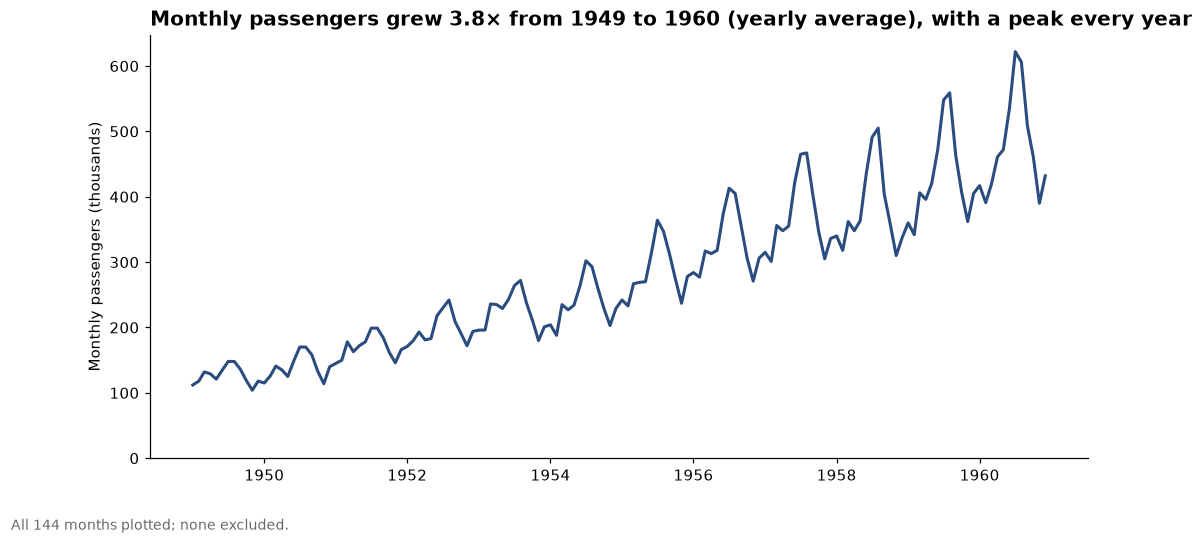

In [2]:
ym = df.groupby("year").passengers.mean()
fig, ax = plt.subplots(figsize=(11, 5)); ax.plot(df.date, df.passengers, color="#2b4c7e", lw=2)
ax.set_ylabel("Monthly passengers (thousands)"); ax.set_ylim(0, None)
ax.set_title(f"Monthly passengers grew {ym.iloc[-1]/ym.iloc[0]:.1f}× from {ym.index[0]} to {ym.index[-1]} (yearly average), with a peak every year")
NOTE(fig, "All 144 months plotted; none excluded."); plt.show()

## 2. The seasonal cycle alone — one line per year

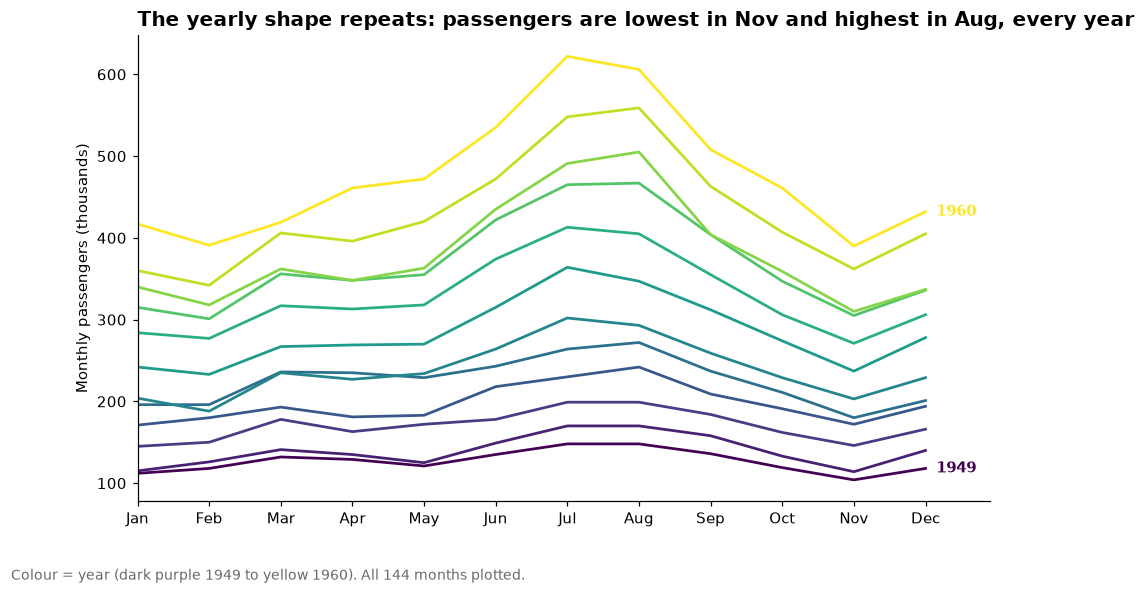

In [3]:
pv = df.pivot(index="m", columns="year", values="passengers")
share = (pv/pv.sum()).mean(axis=1)
peak, low = MN[share.idxmax()-1], MN[share.idxmin()-1]
cmap = plt.cm.viridis; yrs = list(pv.columns)
fig, ax = plt.subplots(figsize=(10, 5.5))
for i, yv in enumerate(yrs): ax.plot(pv.index, pv[yv], color=cmap(i/(len(yrs)-1)), lw=1.8)
for yv in (yrs[0], yrs[-1]): ax.text(12.15, pv[yv].iloc[-1], str(yv), color=cmap(0 if yv==yrs[0] else 1.0), va="center", fontweight="bold")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MN); ax.set_xlim(1, 12.9); ax.set_ylabel("Monthly passengers (thousands)")
ax.set_title(f"The yearly shape repeats: passengers are lowest in {low} and highest in {peak}, every year")
NOTE(fig, "Colour = year (dark purple 1949 to yellow 1960). All 144 months plotted."); plt.show()

## 3. Which month is consistently busiest?

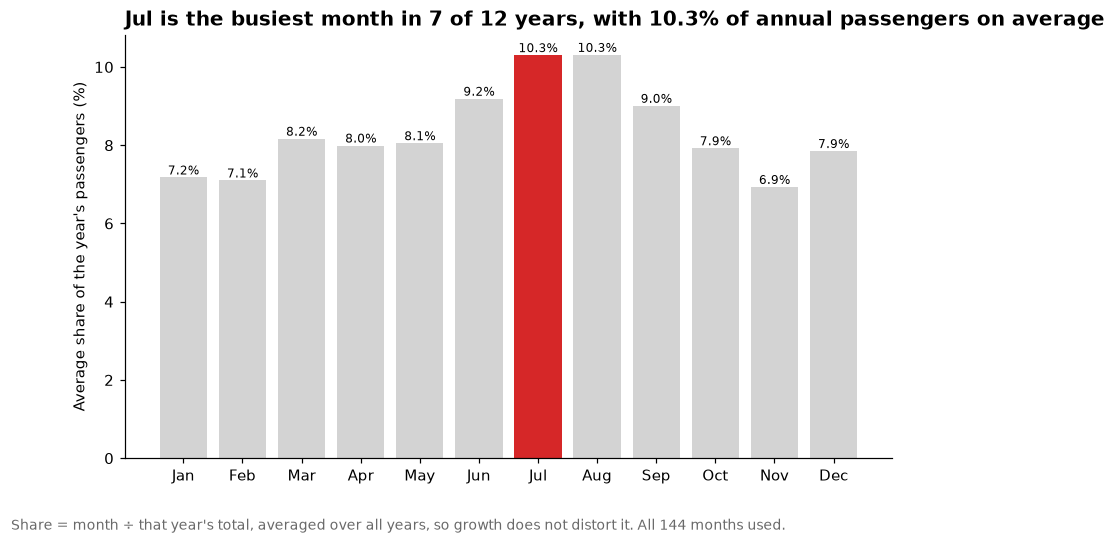

Jul    7
Aug    5


In [4]:
busiest = pv.idxmax()                                   # busiest month in each year
k = int((busiest == busiest.mode()[0]).sum()); top = MN[busiest.mode()[0]-1]
sh = (share*100)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(MN, sh.values, color=["#d62728" if m == top else "lightgrey" for m in MN]); ax.set_ylim(0, None)
ax.bar_label(bars, fmt="%.1f%%", fontsize=8); ax.set_ylabel("Average share of the year's passengers (%)")
ax.set_title(f"{top} is the busiest month in {k} of {len(pv.columns)} years, with {sh.max():.1f}% of annual passengers on average")
NOTE(fig, "Share = month ÷ that year's total, averaged over all years, so growth does not distort it. All 144 months used."); plt.show()
print(busiest.map(lambda m: MN[m-1]).value_counts().to_string())

## Which chart in a report
**Chart 1 (the single line).** It is the only one that shows the real story, growth *and* the seasonal rhythm, in time order, with no processing a reader must undo.
**Chart 2** does not belong beside it: it re-shows the seasonal pattern already visible in chart 1 and removes the time order, so growth is only readable through colour.
**Chart 3** does not belong beside it either: it is a derived average (shares), which repeats the same seasonal point in a different form and answers a narrower question (the peak month). It would be justified only in a report specifically about staffing or capacity for peak months.

## Question: is the bigger swing because seasonality is growing, or just because the airline is growing?

Absolute swing: 44 -> 232 (5.3x) | yearly mean: 127 -> 476 (3.8x)
Swing as % of the year's average: 35% -> 49%


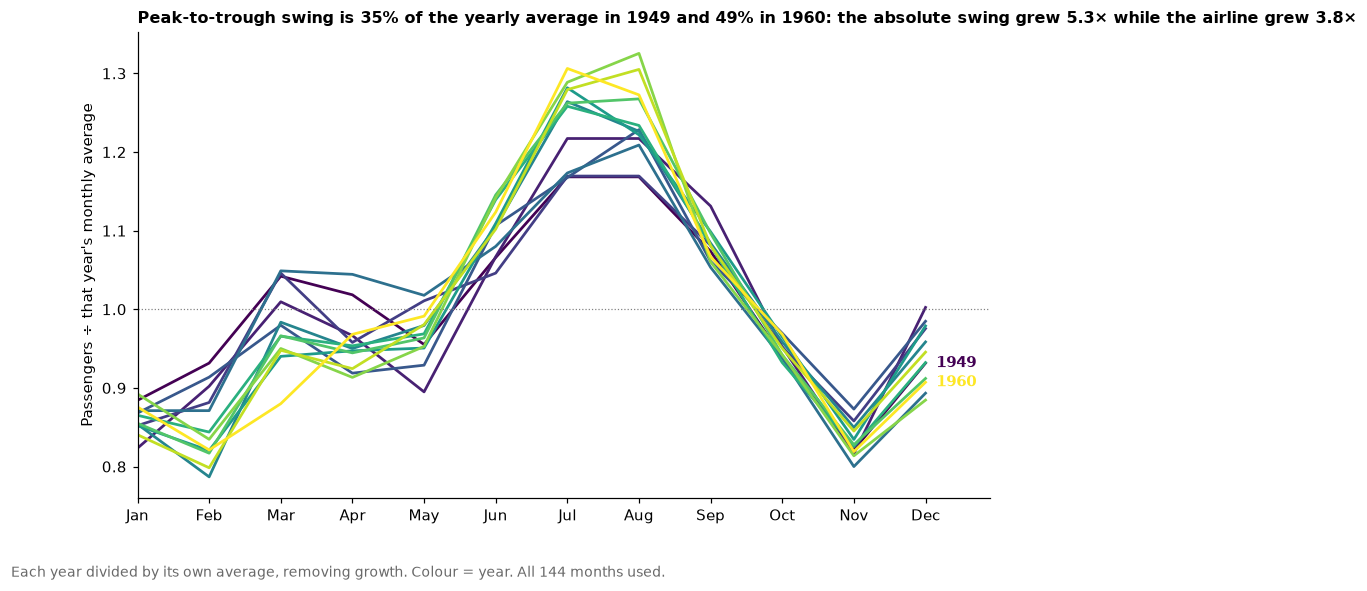

Verdict: growth explains most of the larger swing, but the proportional swing also widened (later curves sit further from 1), so the seasonality grew somewhat as well.


In [5]:
ymean = df.groupby("year").passengers.mean()
swing_abs = pv.max()-pv.min(); swing_rel = swing_abs/ymean
a0, a1, r0, r1 = swing_abs.iloc[0], swing_abs.iloc[-1], swing_rel.iloc[0], swing_rel.iloc[-1]
print(f"Absolute swing: {a0:.0f} -> {a1:.0f} ({a1/a0:.1f}x) | yearly mean: {ymean.iloc[0]:.0f} -> {ymean.iloc[-1]:.0f} ({ymean.iloc[-1]/ymean.iloc[0]:.1f}x)")
print(f"Swing as % of the year's average: {r0:.0%} -> {r1:.0%}")
norm = pv/ymean
fig, ax = plt.subplots(figsize=(10, 5.5))
for i, yv in enumerate(yrs): ax.plot(norm.index, norm[yv], color=cmap(i/(len(yrs)-1)), lw=1.8)
for yv in (yrs[0], yrs[-1]): ax.text(12.15, norm[yv].iloc[-1], str(yv), color=cmap(0 if yv==yrs[0] else 1.0), va="center", fontweight="bold")
ax.axhline(1, color="grey", lw=0.8, ls=":"); ax.set_xticks(range(1, 13)); ax.set_xticklabels(MN); ax.set_xlim(1, 12.9)
ax.set_ylabel("Passengers ÷ that year's monthly average")
ax.set_title(f"Peak-to-trough swing is {r0:.0%} of the yearly average in {yrs[0]} and {r1:.0%} in {yrs[-1]}: the absolute swing grew {a1/a0:.1f}× while the airline grew {ymean.iloc[-1]/ymean.iloc[0]:.1f}×", fontsize=10.5)
NOTE(fig, "Each year divided by its own average, removing growth. Colour = year. All 144 months used."); plt.show()
print("Verdict:", "mostly growth: the curves nearly coincide." if abs(r1-r0) < 0.05 else
      "growth explains most of the larger swing, but the proportional swing also widened (later curves sit further from 1), so the seasonality grew somewhat as well.")

**Chart that settles it:** the one above — each year divided by its own average, so growth is removed. If seasonality were only scaling with the airline, all the year-lines would collapse onto one curve; if later years stand further above and below 1, the seasonality itself grew. Read the printed numbers and the verdict: the absolute swing growing is expected whenever the airline grows, so only the *proportional* swing tells the two causes apart.
(A log-scale line chart of the raw series answers the same question: equal proportional swings look equal in height on a log axis.)